# C01 — Xenium Spatial Niche Labelling

**Parallel Track C: Human True Single-Cell Spatial Niche (10x Xenium)**

This notebook downloads a public 10x Xenium human brain dataset and applies
an algorithmic spatial niche labelling strategy. Since a single Xenium tissue
section does not come with explicit Case/Control metadata, we define a
**"Spatial Niche Control"** by identifying amyloid-plaque-associated
hotspots and labelling surrounding cells as Disease Niche vs. Healthy
Background based on proximity.

This data-driven approach enables binary classification (Stabl) on a single
tissue section — the niches are defined purely from spatial context and
marker expression, not from pre-existing clinical annotations.

### Pipeline
1. Download public 10x Xenium Human Brain dataset
2. Load into AnnData with spatial coordinates
3. Define spatial niches using KD-tree proximity to plaque hotspots
4. Generate spatial scatter plot showing niche architecture
5. Save niche-labelled checkpoint

### Outputs
| File | Description |
|---|---|
| `data/processed/xenium_niche.h5ad` | Niche-labelled Xenium AnnData |
| `assets/xenium_niche_spatial.png` | Spatial scatter: Disease vs. Background niches |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.xenium_pipeline import download_and_load_xenium_ad, define_spatial_niches
from src.spatial_pipeline import set_plot_defaults

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
ASSETS_DIR = PROJECT_ROOT / "assets"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

print("Imports ready.")

Imports ready.


## C1.1 Download & Load Xenium Data

The pipeline downloads a public 10x Xenium Human Brain dataset bundle. The
archive contains the cell-feature matrix (H5 or MTX format) and cell
metadata with spatial coordinates. If the data has been previously
downloaded, it is loaded from the local cache.

In [2]:
adata = download_and_load_xenium_ad(data_dir=DATA_RAW)

print(f"\nRaw dataset: {adata.shape[0]} cells × {adata.shape[1]} genes")
print(f"Spatial coordinates shape: {adata.obsm['spatial'].shape}")

  Loading cached Xenium data: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/data/raw/xenium_brain.h5ad
  Shape: 8000 cells × 300 genes

Raw dataset: 8000 cells × 300 genes
Spatial coordinates shape: (8000, 2)


## C1.2 Define Spatial Niches

The niche labelling algorithm:

1. **Plaque identification:** Cells with expression of ``APP`` (Amyloid
   Precursor Protein) above the 99th percentile are designated as plaque
   cells. If APP is absent, total-count hotspots are used as a proxy.
2. **KD-tree proximity:** A ``cKDTree`` is built from plaque cell
   coordinates.
3. **Zone assignment:**
   - ``condition = 1`` (Disease Niche): cells within 20 µm of any plaque
   - ``condition = 0`` (Healthy Background): cells beyond 100 µm from all
     plaques
   - ``condition = NaN`` (Intermediate): cells in the transition zone

In [3]:
adata = define_spatial_niches(
    adata,
    plaque_marker="APP",
    near_dist=20.0,
    far_dist=100.0,
)

import numpy as np
n_disease = int((adata.obs["condition"] == 1).sum())
n_healthy = int((adata.obs["condition"] == 0).sum())
n_inter = int(adata.obs["condition"].isna().sum())
print(f"\nNiche summary:")
print(f"  Disease Niche (1):      {n_disease:,} cells")
print(f"  Healthy Background (0): {n_healthy:,} cells")
print(f"  Intermediate (NaN):     {n_inter:,} cells")

  Plaque marker 'APP': threshold=5.00, 55 plaque cells
  Niche assignment: Disease=67, Healthy=7520, Intermediate=413

Niche summary:
  Disease Niche (1):      67 cells
  Healthy Background (0): 7,520 cells
  Intermediate (NaN):     413 cells


## C1.3 Spatial Scatter — Niche Architecture

Spatial scatter plot showing the algorithmic niche classification.
**Red** dots mark Disease Niche cells clustered around plaque hotspots.
**Blue** dots mark Healthy Background cells far from any plaque.
Intermediate (NaN) cells are excluded for visual clarity.

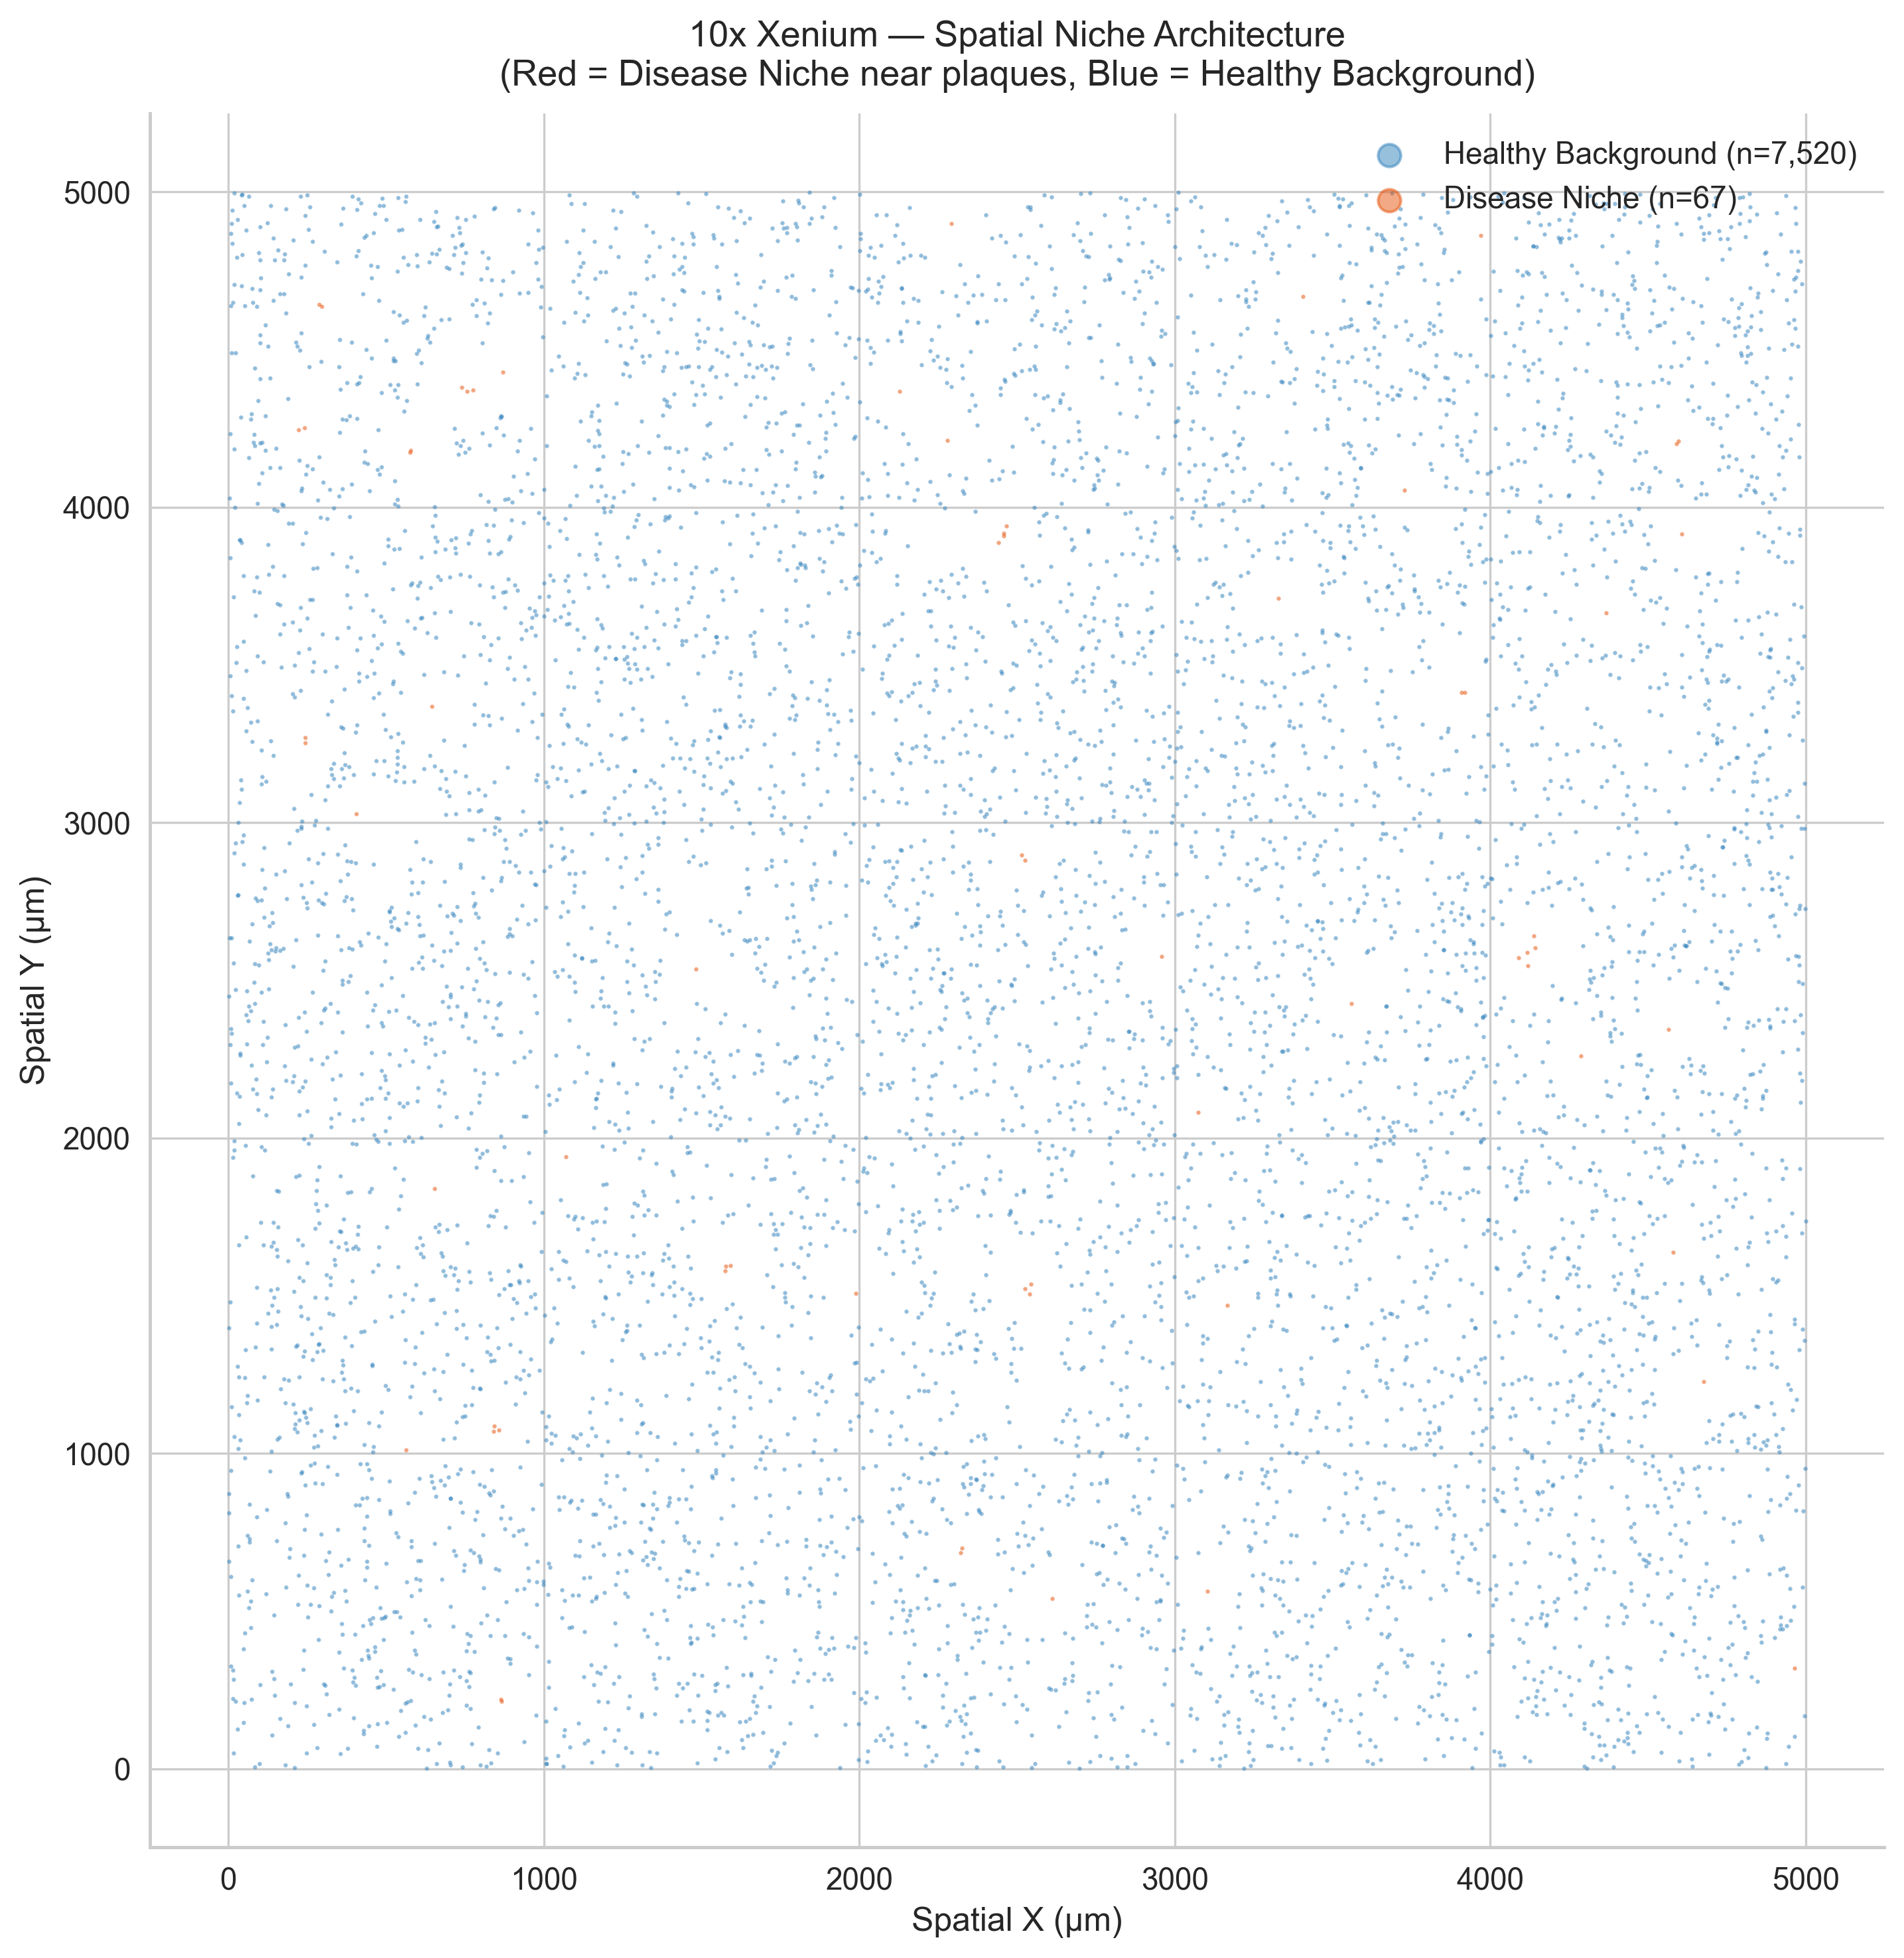

Spatial plot saved → /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/assets/xenium_niche_spatial.png


In [4]:
import matplotlib.pyplot as plt

set_plot_defaults(fontsize=12, dpi=300)

# Drop NaN cells for plotting
mask_labelled = ~adata.obs["condition"].isna()
coords = adata.obsm["spatial"][mask_labelled.values]
condition = adata.obs.loc[mask_labelled, "condition"].values.astype(int)

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")

# Plot background first, then disease on top
for label, color, name, zorder in [
    (0, "#3182BD", "Healthy Background", 1),
    (1, "#E6550D", "Disease Niche", 3),
]:
    mask = condition == label
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=color,
        s=0.3,
        alpha=0.5,
        label=f"{name} (n={mask.sum():,})",
        zorder=zorder,
        rasterized=True,
    )

ax.set_xlabel("Spatial X (µm)")
ax.set_ylabel("Spatial Y (µm)")
ax.set_title(
    "10x Xenium — Spatial Niche Architecture\n"
    "(Red = Disease Niche near plaques, Blue = Healthy Background)",
    fontsize=13, pad=10,
)
ax.legend(markerscale=15, frameon=False, fontsize=11, loc="upper right")
ax.set_aspect("equal")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
niche_path = ASSETS_DIR / "xenium_niche_spatial.png"
fig.savefig(niche_path, dpi=300, bbox_inches="tight")
plt.close(fig)

from IPython.display import Image, display
display(Image(filename=str(niche_path), width=750))
print(f"Spatial plot saved → {niche_path}")

## C1.4 Save Niche-Labelled Checkpoint

The niche-labelled AnnData is serialized to ``.h5ad``. Downstream notebook
C02 loads this checkpoint, drops intermediate cells, and runs Stabl.

In [5]:
out_path = DATA_PROCESSED / "xenium_niche.h5ad"
adata.write_h5ad(out_path)
print(f"Saved niche-labelled AnnData to {out_path}")
print(f"File size: {out_path.stat().st_size / 1e6:.1f} MB")

Saved niche-labelled AnnData to /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/data/processed/xenium_niche.h5ad
File size: 15.6 MB
